# No-show prediction (CareBridge, Assessment 3)

This notebook trains two models to predict whether a patient will miss an appointment, and compares them with simple baselines.

- **Data:** [Medical Appointment No Shows](https://www.kaggle.com/datasets/joniarroba/noshowappointments) on Kaggle (CC BY-NC-SA 4.0). Real, anonymised appointments from public clinics in Vitória, Brazil, April to June 2016. Used offline only; it never enters the CareBridge database.
- **Setup:** download the CSV to `noshow/data/KaggleV2-May-2016.csv`, install `requirements-eval.txt`, then run all cells.
- The data loading, features and models live in `train.py`, so the notebook and the script always give the same numbers. The full written report is `NOSHOW_REPORT.md`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve

from train import FEATURES, best_f1_threshold, evaluate, load, models, time_split

pd.set_option("display.float_format", "{:.3f}".format)

## 1. Load and clean

Rows with an impossible age, or with the appointment before the booking date, are dropped.

History features (`prior_appointments`, `prior_no_shows`, `prior_no_show_rate`) count only appointments on **earlier days**. Same-day outcomes are not known when the prediction is made, so including them would leak the answer.

In [2]:
df, cleaning = load()
print(cleaning)
print(f"No-show rate: {df['no_show'].mean():.1%}")
df[FEATURES + ["no_show"]].head()

{'raw_rows': 110527, 'dropped_bad_age': 6, 'dropped_negative_lead_time': 5, 'clean_rows': 110516}
No-show rate: 20.2%


,age,is_female,lead_days,same_day,weekday,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,prior_appointments,prior_no_shows,prior_no_show_rate,no_show
0,62,1,0,1,4,0,1,0,0,0,0,0,0,0.000,0
1,56,0,0,1,4,0,0,0,0,0,0,0,0,0.000,0
2,62,1,0,1,4,0,0,0,0,0,0,0,0,0.000,0
3,8,1,0,1,4,0,0,0,0,0,0,0,0,0.000,0
4,56,1,0,1,4,0,1,1,0,0,0,0,0,0.000,0


## 2. A first look: lead time and reminders

,appointments,no_show_rate,sms_sent
lead_days,,,
same day,38561,0.046,0.000
1-2 days,11938,0.227,0.000
3-7 days,20245,0.250,0.570
8-30 days,29395,0.317,0.596
over 30 days,10377,0.330,0.618


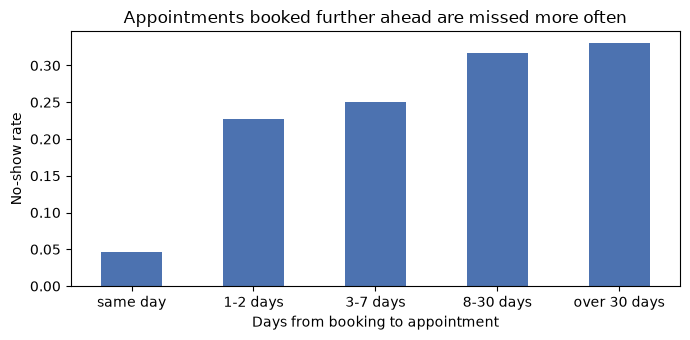

In [3]:
bins = pd.cut(df["lead_days"], [-1, 0, 2, 7, 30, 200], labels=["same day", "1-2 days", "3-7 days", "8-30 days", "over 30 days"])
lead = df.groupby(bins, observed=True).agg(appointments=("no_show", "size"), no_show_rate=("no_show", "mean"), sms_sent=("sms_received", "mean"))
display(lead)

ax = lead["no_show_rate"].plot.bar(color="#4c72b0", rot=0, figsize=(7, 3.5))
ax.set_ylabel("No-show rate")
ax.set_xlabel("Days from booking to appointment")
ax.set_title("Appointments booked further ahead are missed more often")
plt.tight_layout()

No SMS reminder was sent for appointments booked 2 days or less ahead. So `sms_received` partly stands in for lead time; it does not show that reminders cause no-shows.

## 3. Split by time

The model learns from older appointments and is tested on newer ones, as it would be used in a real clinic. A random split would let it learn from the future.

In [4]:
train, val, test, split = time_split(df)
pd.DataFrame(split).T

,rows,from,to,no_show_rate
train,63529,2016-04-29,2016-05-19,0.209
validation,20538,2016-05-20,2016-05-31,0.201
test,26449,2016-06-01,2016-06-08,0.185


## 4. Baselines

In [5]:
y_val = val["no_show"].to_numpy()
y_test = test["no_show"].to_numpy()

rows = {}
rows["Baseline: nobody no-shows"] = evaluate(y_test, np.zeros_like(y_test), None)
rows["Baseline: earlier no-show"] = evaluate(y_test, (test["prior_no_shows"] > 0).to_numpy().astype(int), None)

## 5. Train the models and tune the threshold

For each model:
1. Train on the train set.
2. Pick the threshold with the best F1 on the validation set.
3. Refit on train plus validation, then score the test set once with that threshold.

In [6]:
fitted, scores, thresholds = {}, {}, {}
for name, model in models().items():
    model.fit(train[FEATURES], train["no_show"])
    thresholds[name] = best_f1_threshold(y_val, model.predict_proba(val[FEATURES])[:, 1])

    final = models()[name]
    fit_rows = pd.concat([train, val])
    final.fit(fit_rows[FEATURES], fit_rows["no_show"])
    fitted[name] = final
    scores[name] = final.predict_proba(test[FEATURES])[:, 1]

labels = {"logistic_regression": "Logistic regression", "gradient_boosting": "Gradient boosting"}
for name, label in labels.items():
    rows[f"{label} (0.5)"] = evaluate(y_test, (scores[name] >= 0.5).astype(int), scores[name])
    rows[f"{label} (tuned {thresholds[name]:.3f})"] = evaluate(y_test, (scores[name] >= thresholds[name]).astype(int), scores[name])

## 6. Results on the test set

In [7]:
results = pd.DataFrame(rows).T[["accuracy", "precision", "recall", "f1", "pr_auc", "roc_auc", "flagged_share"]]
results

,accuracy,precision,recall,f1,pr_auc,roc_auc,flagged_share
Baseline: nobody no-shows,0.815,0.000,0.000,0.000,None,None,0.000
Baseline: earlier no-show,0.715,0.247,0.266,0.256,None,None,0.199
Logistic regression (0.5),0.814,0.453,0.046,0.083,0.334,0.724,0.019
Logistic regression (tuned 0.231),0.607,0.290,0.782,0.423,0.334,0.724,0.497
Gradient boosting (0.5),0.816,0.522,0.038,0.071,0.349,0.735,0.013
Gradient boosting (tuned 0.246),0.658,0.307,0.679,0.423,0.349,0.735,0.408


**How to read this**

- "Nobody no-shows" has the best accuracy but finds zero no-shows. Accuracy alone is misleading when no-shows are the minority.
- At the default 0.5 threshold, both models flag almost nobody. Tuning the threshold raises recall sharply.
- A random model has a PR-AUC equal to the no-show rate (about 0.185 here). Both models reach about 0.35.

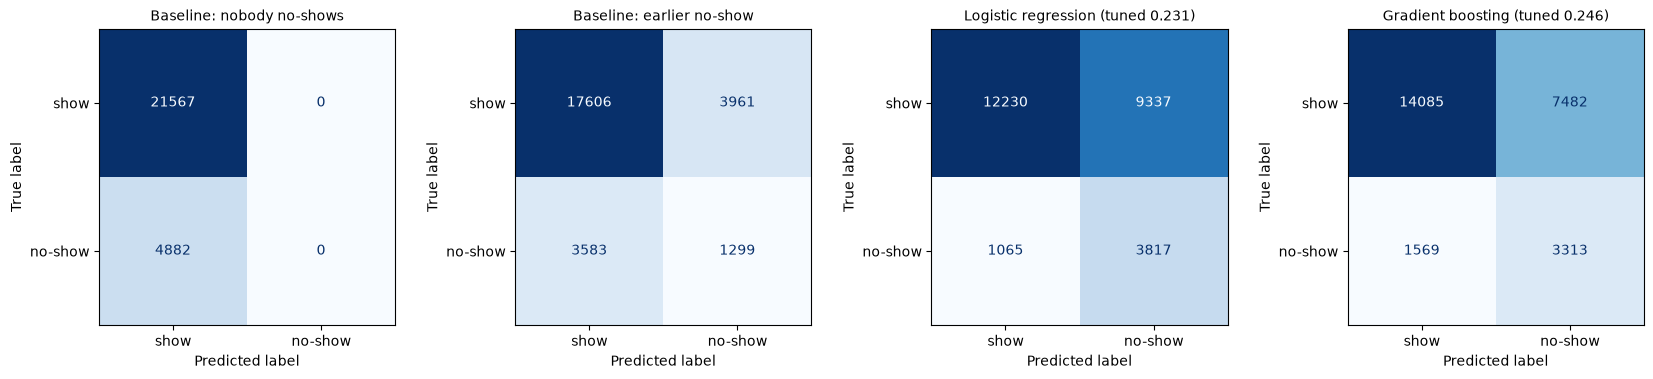

In [8]:
names = ["Baseline: nobody no-shows", "Baseline: earlier no-show"] + [k for k in rows if "tuned" in k]
fig, axes = plt.subplots(1, len(names), figsize=(4.2 * len(names), 3.8))
for ax, name in zip(axes, names):
    c = rows[name]["confusion"]
    matrix = np.array([[c["tn"], c["fp"]], [c["fn"], c["tp"]]])
    ConfusionMatrixDisplay(matrix, display_labels=["show", "no-show"]).plot(ax=ax, colorbar=False, values_format="d", cmap="Blues")
    ax.set_title(name, fontsize=10)
plt.tight_layout()

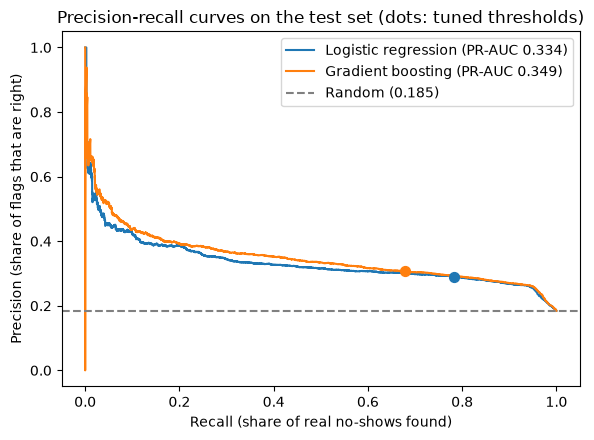

In [9]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for name, label in labels.items():
    precision, recall, _ = precision_recall_curve(y_test, scores[name])
    ax.plot(recall, precision, label=f"{label} (PR-AUC {rows[f'{label} (0.5)']['pr_auc']:.3f})")
    t = rows[f"{label} (tuned {thresholds[name]:.3f})"]
    ax.scatter(t["recall"], t["precision"], s=50, zorder=3)
ax.axhline(y_test.mean(), color="grey", linestyle="--", label=f"Random ({y_test.mean():.3f})")
ax.set_xlabel("Recall (share of real no-shows found)")
ax.set_ylabel("Precision (share of flags that are right)")
ax.set_title("Precision-recall curves on the test set (dots: tuned thresholds)")
ax.legend()
plt.tight_layout()

## 7. What drives the prediction

Permutation importance: how much test PR-AUC drops when one feature is shuffled (gradient boosting).

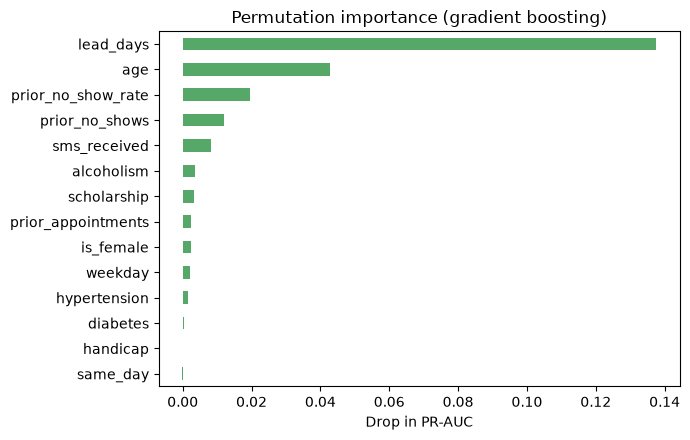

In [10]:
perm = permutation_importance(fitted["gradient_boosting"], test[FEATURES], y_test, scoring="average_precision", n_repeats=5, random_state=42)
importance = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
ax = importance.plot.barh(color="#55a868", figsize=(7, 4.5))
ax.set_xlabel("Drop in PR-AUC")
ax.set_title("Permutation importance (gradient boosting)")
plt.tight_layout()

## 8. Conclusion

- **Recommended model:** gradient boosting with the tuned threshold. It has the same F1 as logistic regression, a higher PR-AUC, and flags fewer appointments.
- **Use:** with about 30% precision, a flag should trigger a cheap action such as an extra reminder or a confirmation call, never a penalty for the patient.
- **Threshold choice:** the F1 threshold weighs precision and recall equally. A clinic with few staff for calls can raise it to flag fewer, higher-risk appointments.
- **Limits:** Brazil 2016 data, about six weeks of history, and no specialty or time-of-day columns. Retrain on CareBridge's own appointments once enough exist.